Name :- Sandesh Arun Mohite

Roll No :- 23

Division :- T.Y(AIML)-A



# **Multiclass Classification using Logistic Regression :-**

##Assignment :-

Predict Employee Satisfaction Level (Low, Medium, High) based on:

Study Hours

Monthly_Salary Percentage


## Step 1: Import Required Libraries


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report



## Step 2: Create a Simple Multiclass Dataset
Target Variable:
Classes:

0 → Low Satisfaction

1 → Medium Satisfaction

2 → High Satisfaction

In [ ]:
data = {
    'Working_Hours': [
        35, 40, 45, 38, 42, 48, 50, 55, 60, 52,
        44, 58, 36, 41, 47, 49, 53, 57, 39, 43,
        46, 51, 54, 59, 37, 45, 50, 56, 48, 60
    ],

    'Monthly_Salary': [
        18000, 22000, 25000, 20000, 28000, 32000, 35000, 42000, 50000, 40000,
        30000, 48000, 19000, 24000, 29000, 33000, 38000, 45000, 21000, 27000,
        31000, 36000, 41000, 52000, 18500, 26000, 37000, 46000, 34000, 55000
    ],

    'Satisfaction': [
        0, 0, 0, 0, 1, 1, 2, 2, 2, 2,
        1, 2, 0, 0, 1, 1, 2, 2, 0, 1,
        1, 2, 2, 2, 0, 1, 2, 2, 1, 2
    ]
}

df = pd.DataFrame(data)
df


,Working_Hours,Monthly_Salary,Satisfaction
0,35,18000,0
1,40,22000,0
2,45,25000,0
3,38,20000,0
4,42,28000,1
5,48,32000,1
6,50,35000,2
7,55,42000,2
8,60,50000,2
9,52,40000,2



## Step 3: Explore the Dataset


In [ ]:
df.shape

(30, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Working_Hours   30 non-null     int64
 1   Monthly_Salary  30 non-null     int64
 2   Satisfaction    30 non-null     int64
dtypes: int64(3)
memory usage: 852.0 bytes


In [ ]:
df.describe()

,Working_Hours,Monthly_Salary,Satisfaction
count,30.000000,30.000000,30.000000
mean,47.933333,33416.666667,1.166667
std,7.487614,10612.357252,0.833908
min,35.000000,18000.000000,0.000000
25%,42.250000,25250.000000,0.250000
50%,48.000000,32500.000000,1.000000
75%,53.750000,40750.000000,2.000000
max,60.000000,55000.000000,2.000000



## Step 4: Split Features and Target


In [ ]:
X = df[['Working_Hours', 'Monthly_Salary']]
y = df['Satisfaction']


## Step 5: Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 6: Create and Train Logistic Regression Model


In [ ]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')


## Step 7: Model Prediction and Evaluation


In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6




## Step 8: Visualization


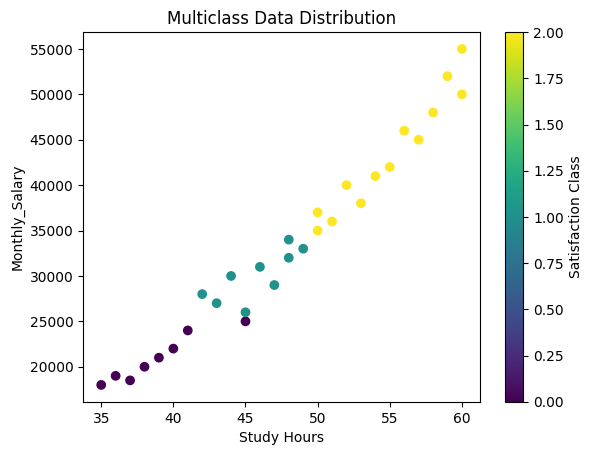

In [ ]:
plt.scatter(df['Working_Hours'], df['Monthly_Salary'], c=df['Satisfaction'], cmap='viridis')
plt.xlabel('Study Hours')
plt.ylabel('Monthly_Salary')
plt.title('Multiclass Data Distribution')
plt.colorbar(label='Satisfaction Class')
plt.show()


## Step 9: Prediction Using User Input


In [ ]:
Working_Hours = float(input("Enter Working hours: "))
Monthly_Salary = float(input("Enter Monthly_Salary percentage: "))

new_data = [[Working_Hours, Monthly_Salary]]
prediction = model.predict(new_data)

labels = {0: 'Low', 1: 'Medium', 2: 'High'}
print("Predicted Satisfaction Level:", labels[prediction[0]])

Enter Working hours: 50
Enter Monthly_Salary percentage: 40000
Predicted Satisfaction Level: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('MCModel.pkl','wb'))

**Flask Code**

Save this file with 'app.py'

In [ ]:
from flask import Flask, render_template, request
import pickle

app = Flask(__name__)

# Load Trained Model
model = pickle.load(open("MCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read input values
    working_hours = float(request.form['working_hours'])
    monthly_salary = float(request.form['monthly_salary'])

    # Prediction
    prediction = model.predict([[working_hours, monthly_salary]])

    # Convert class number into satisfaction level
    if prediction[0] == 0:
        satisfaction = "Low Satisfaction"

    elif prediction[0] == 1:
        satisfaction = "Medium Satisfaction"

    else:
        satisfaction = "High Satisfaction"

    return render_template(
        "index.html",
        prediction_text=f"Predicted Job Satisfaction : {satisfaction}"
    )


if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file with 'index.html'

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Employee Satisfaction Predictor</title>

<style>

*{
    margin:0;
    padding:0;
    box-sizing:border-box;
    font-family:Arial, Helvetica, sans-serif;
}

body{
    background:#eef5ff;
    display:flex;
    justify-content:center;
    align-items:center;
    min-height:100vh;
}

.container{
    width:480px;
    background:white;
    padding:35px;
    border-radius:15px;
    box-shadow:0px 10px 25px rgba(0,0,0,.2);
}

h1{
    text-align:center;
    color:#1565c0;
}

h3{
    text-align:center;
    color:#555;
    margin-top:8px;
    margin-bottom:25px;
}

label{
    font-weight:bold;
    display:block;
    margin-top:15px;
    margin-bottom:6px;
}

input{
    width:100%;
    padding:12px;
    border:1px solid #ccc;
    border-radius:8px;
    font-size:16px;
}

button{
    width:100%;
    margin-top:25px;
    padding:13px;
    background:#1565c0;
    color:white;
    border:none;
    border-radius:8px;
    font-size:18px;
    cursor:pointer;
    transition:.3s;
}

button:hover{
    background:#0d47a1;
}

.result{
    margin-top:25px;
    background:#e8f5e9;
    padding:18px;
    border-radius:8px;
    text-align:center;
    color:green;
    font-size:21px;
    font-weight:bold;
}

footer{
    text-align:center;
    margin-top:20px;
    color:#777;
    font-size:13px;
}

</style>

</head>

<body>

<div class="container">

<h1>Employee Satisfaction Predictor</h1>

<h3>Multiclass Classification using Logistic Regression</h3>

<form action="/predict" method="POST">

<label>Working Hours per Week</label>

<input
type="number"
name="working_hours"
step="1"
min="1"
max="100"
placeholder="Enter Working Hours"
required>

<label>Monthly Salary (₹)</label>

<input
type="number"
name="monthly_salary"
step="500"
min="5000"
placeholder="Enter Monthly Salary"
required>

<button type="submit">
Predict Satisfaction
</button>

</form>

{% if prediction_text %}

<div class="result">
{{ prediction_text }}
</div>

{% endif %}

<footer>
Employee Job Satisfaction Prediction
</footer>

</div>

</body>

</html>